### Learning with Ensembles

Let's implement the probability mass function to compare an idealistic ensemble classifier to a base classifier over a range of different base error rates:

In [1]:
from scipy.special import comb
import math

def ensemble_error(n_classifier, error):
    k_start = int(math.ceil(n_classifier / 2.0))
    probs = [comb(n_classifier, k) * error**k * (1-error)**(n_classifier-k)
             for k in range(k_start, n_classifier + 1)]
    return sum(probs)

print(ensemble_error(n_classifier=11, error=0.25))

0.03432750701904297


Now, we can compute the ensemble error rates for a range of different base errors from 0.0 to 1.0 to visualize the relationship between ensemble and base errors in a line graph:

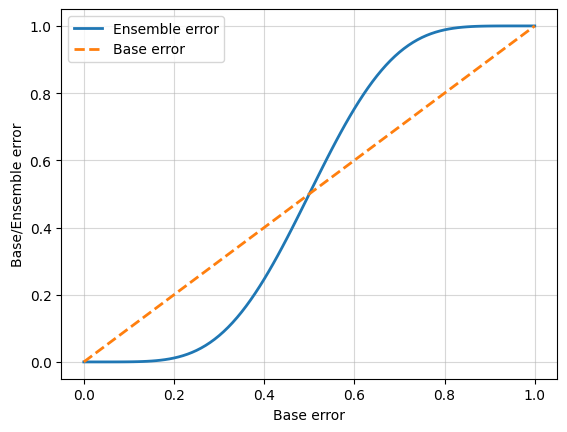

In [2]:
import numpy as np
import matplotlib.pyplot as plt

error_range = np.arange(0.0, 1.01, 0.01)
ens_errors = [ensemble_error(n_classifier=11, error=error) 
              for error in error_range]

plt.plot(error_range, ens_errors,
         label='Ensemble error',
         linewidth=2)
plt.plot(error_range, error_range,
         label='Base error', linestyle='--',
         linewidth=2)
plt.xlabel('Base error')
plt.ylabel('Base/Ensemble error')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.show()

As you can see, the error probability of an ensemble is always better than the error of an individual base classifier, as long as the base classifier performs better than random guessing ($\epsilon$ < 0.5)

### Implementing a Simple Majority Vote Classifier

Let's implement a simple ensemble classifier for majority voting now. The algorithm we are going to implement will allow us to combine different classification algorithms associated with individual weights for confidence. Our goal is to build a stronger meta-classifier that balances out the individual classifiers' weaknesses on a particular dataset. 

To translate the concept of weighted majority vote to Python, we can use the argmax and bincount functions from numpy, counting the number of occurrences of each class label and returning the index position of the highest count, corresponding to the majority class label (assuming class labels start at 0)

In [3]:
np.argmax(np.bincount([0, 0, 1],
          weights=[0.2, 0.2, 0.6]))

np.int64(1)

To implement the weighted majority vote based on class probabilities, we can make use of average and argmax function from numpy:

In [4]:
ex = np.array([[0.9, 0.1],
               [0.8, 0.2],
               [0.4, 0.6]])

p = np.average(ex, axis=0, weights=[0.2, 0.2, 0.6])

print(p)
print(np.argmax(p))

[0.58 0.42]
0


We can now implement our own majority vote classifier:

In [5]:
from sklearn.base import BaseEstimator
from sklearn.base import ClassifierMixin
from sklearn.preprocessing import LabelEncoder
from sklearn.base import clone
from sklearn.pipeline import _name_estimators   
import numpy as np
import operator

class MajorityVoteClassifier(ClassifierMixin, BaseEstimator):
    def __init__(self, classifiers, vote='classlabel', weights=None):
        self.classifiers = classifiers
        self.named_classifiers = {
            key: value 
            for key, value in _name_estimators(classifiers)
        }
        self.vote = vote
        self.weights = weights
    
    def fit(self, X, y):
        if self.vote not in ('probability', 'classlabel'):
            raise ValueError(f"vote must be 'probability'"
                             f"of 'classlabel'"
                             f"; got (vote={self.vote})")
        
        if self.weights and len(self.weights) != len(self.classifiers):
            raise ValueError(f'Number of classifiers and'
                             f' weights must be equal'
                             f'; got {len(self.weights)} weights,'
                             f' {len(self.classifiers)} classifiers')
        
        # Use LabelEncoder to ensure class labels start with 0
        # which is important for np.argmax
        # call in self.predict
        self.lablenc_ = LabelEncoder()
        self.lablenc_.fit(y)
        self.classes_ = self.lablenc_.classes_
        self.classifiers_ = []
        for clf in self.classifiers:
            fitted_clf = clone(clf).fit(X, self.lablenc_.transform(y))
            self.classifiers_.append(fitted_clf)
        
        return self
    
    def predict(self, X):
        if self.vote == 'probability':
            maj_vote = np.argmax(self.predict_proba(X), axis =1)
        else: # 'classlabel' vote
            predictions = np.asarray([clf.predict(X) for clf in self.classifiers_]).T

            maj_vote = np.apply_along_axis(
                lambda x: np.argmax(
                    np.bincount(x, weights=self.weights)
                ),
                axis=1, arr=predictions
            )
        maj_vote = self.lablenc_.inverse_transform(maj_vote)
        return maj_vote
    
    def predict_proba(self, X):
        probas = np.asarray([clf.predict_proba(X)
                             for clf in self.classifiers_])
        
        avg_proba = np.average(probas, axis=0, 
                               weights=self.weights)
        return avg_proba
    
    def get_params(self, deep=True):
        if not deep:
            return super().get_params(deep=False)
        else:
            out = self.named_classifiers.copy()
            for name, step in self.named_classifiers.items():
                for key, value in step.get_params(deep=True).items():
                    out[f'{name}__{key}'] = value
            
            return out



We used the BaseEstimator and ClassifierMixin parent classes to get some base functionality for free, including the get_params and set_params methods to set and return the classifier's parameters, as well as the score method to calculate the prediction accuracy. In the predict method, we are able to initialize the MajorityVoteClassifier with 'classlabel' or 'probability' to predict the class label based on majority vote for class labels or class membership probabilities. We also modified the get_params method to use the _name_estimators function to access the parameters of individual classifiers in the ensemble, it will be useful when we use grid search for hyperparameter tuning.

There is a scikit-learn implementation in sklearn.ensemble.VotingClassifier that is more sophisticated than our MajorityVoteClassifier for practical use.

### Using the Majority Voting Principle to Make Predictions

Let's use the familiar Iris dataset with only 2 features (sepal width and petal length) to make the classification task more challenging. Although our MajorityVoteClassifier generalizes to multiclass problems, we will only classify flower examples from Iris-versicolor and Iris-virginica and compute the ROC AUC later.

In [6]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

iris = datasets.load_iris()
X, y = iris.data[50:, [1, 2]], iris.target[50:]
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.5,
                                                    random_state=1,
                                                    stratify=y)

Using the training dataset, we now will train three different classifiers:
- Logistic regression classifier
- Decision tree classifier
- k-nearest neighbors classifier
  
We will then evaluate the model performance of each classifier via 10-fold cross-validation on the training dataset before combining them into an ensemble classifier:

In [7]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import numpy as np

clf1 = LogisticRegression(l1_ratio = 0,
                          C=0.001,
                          solver='lbfgs',
                          random_state=1)
clf2 = DecisionTreeClassifier(max_depth=1,
                              criterion='entropy',
                              random_state=0)
clf3 = KNeighborsClassifier(n_neighbors=1,
                            p=2,
                            metric='minkowski')
pipe1 = Pipeline([['sc', StandardScaler()],
                  ['clf', clf1]])
pipe3 = Pipeline([['sc', StandardScaler()],
                  ['clf', clf3]])
clf_labels = ['Logistic regression', 'Decision tree', 'KNN']
print('10-fold cross validation:\n')
for clf, label in zip([pipe1, clf2, pipe3], clf_labels):
    scores = cross_val_score(estimator=clf,
                             X=X_train,
                             y=y_train,
                             cv=10,
                             scoring='roc_auc')
    print(f'ROC AUC: {scores.mean():.2f} ± {scores.std():.2f} [{label}]')


10-fold cross validation:

ROC AUC: 0.92 ± 0.15 [Logistic regression]
ROC AUC: 0.87 ± 0.18 [Decision tree]
ROC AUC: 0.85 ± 0.13 [KNN]


We trained logistic regression and k-nearest neighbors classifiers as part of a pipeline, because these algorithms are not scale-invariant, in contrast to decision trees. Now, let's combine the individual classifiers for majority rule:

In [8]:
mv_clf = MajorityVoteClassifier(
    classifiers=[pipe1, clf2, pipe3]
)
clf_labels += ['Majority voting']
all_clf = [pipe1, clf2, pipe3, mv_clf]

for clf, label in zip(all_clf, clf_labels):
    scores = cross_val_score(estimator=clf,
                             X=X_train,
                             y=y_train,
                             cv=10,
                             scoring='roc_auc')
    print(f'ROC AUC: {scores.mean():.2f} ± {scores.std():.2f} [{label}]')

ROC AUC: 0.92 ± 0.15 [Logistic regression]
ROC AUC: 0.87 ± 0.18 [Decision tree]
ROC AUC: 0.85 ± 0.13 [KNN]
ROC AUC: 0.98 ± 0.05 [Majority voting]


As we can see, the performance of the MajorityVotiingClassifier has improved over the individual classifiers in the 10-fold cross-validation evaluation.

### Evaluating and Tuning the Ensemble Classifier

We are going to compute the ROC curves from the test dataset to check that MajorityVoteClassifier generalizes well to unseen data. We must remember that the test dataset is not to be used for model selection, its purpose is to merely report an unbiased estimate of the generalization performance of a classifier system:

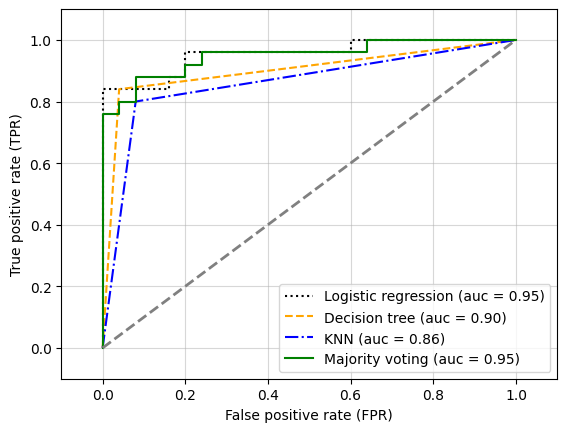

In [9]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
colors = ['black', 'orange', 'blue', 'green']
linestyles = [':', '--', '-.', '-']
for clf, label, clr, ls in \
    zip(all_clf, clf_labels, colors, linestyles):
    y_pred = clf.fit(X_train, y_train).predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_true=y_test, 
                                     y_score=y_pred)
    roc_auc = auc(x=fpr, y=tpr)
    plt.plot(fpr, tpr,
             color=clr,
             linestyle=ls,
             label=f'{label} (auc = {roc_auc:.2f})')
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 
         linestyle='--',
         color='gray',
         linewidth=2)
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.grid(alpha=0.5)
plt.xlabel('False positive rate (FPR)')
plt.ylabel('True positive rate (TPR)')
plt.show()



As we can see in the resulting ROC, the ensemble classifier also performs well on the test dataset. However, you can see that the logistic regression classifier also performs similarly well on the same dataset, which is probably due to the high variance (the sensitivity of how we split the dataset) given the small size of the dataset.

Since we only selected two features for the classification examples, it would be interesting to see what the decision region of the ensemble classifier actually looks like. Although it is not necessary to standardize the training features prior to model fitting, because our logistic regression and k-nearest neighbors pipelines will automatically take care of it, we will standardize the training dataset so that the decision regions of the decision tree will be on the same scale for visual purposes:

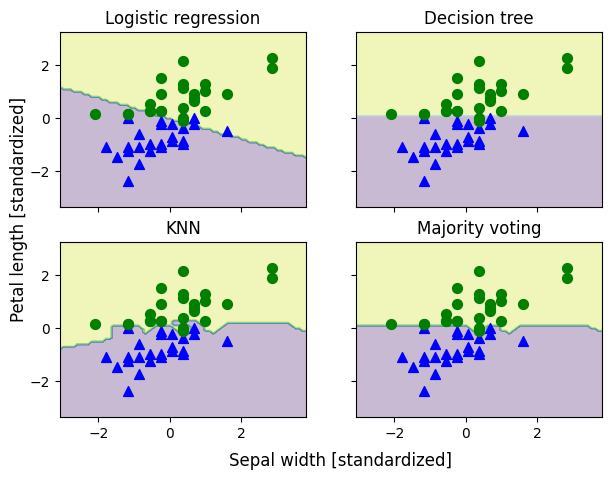

In [10]:
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
from itertools import product
x_min = X_train_std[:, 0].min() - 1
x_max = X_train_std[:, 0].max() + 1
y_min = X_train_std[:, 1].min() - 1
y_max = X_train_std[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
f, axarr = plt.subplots(nrows=2, ncols=2,
                        sharex='col',
                        sharey='row',
                        figsize=(7,5))

for idx, clf, tt in zip(product([0, 1], [0, 1]),
                        all_clf, clf_labels):
    clf.fit(X_train_std, y_train)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axarr[idx[0], idx[1]].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx[0], idx[1]].scatter(X_train_std[y_train==0, 0], 
                                  X_train_std[y_train==0, 1], 
                                  c='blue',
                                  marker='^',
                                  s=50)
    axarr[idx[0], idx[1]].scatter(X_train_std[y_train==1, 0], 
                                  X_train_std[y_train==1, 1], 
                                  c='green',
                                  marker='o',
                                  s=50)
    axarr[idx[0], idx[1]].set_title(tt)

plt.text(-3.5, -5,
         s='Sepal width [standardized]',
         ha='center', va='center',fontsize=12)
plt.text(-12.5, 4.5,
         s='Petal length [standardized]',
         ha='center', va='center',
         fontsize=12, rotation=90)
plt.show()

Interestingly, but also as expected, the decision regions of the ensemble classifier seem to be a hybrid of the decision regions from the individual classifiers. At first glance, the majority vote decision boundary looks a lot like the decision of the decision tree stump, however you can also notice the nonlinearity from the k-nearest neighbor classifier mixed in. Let's call the get_params method to get a basic idea of how we can access the individual parameters inside a GridSearchCV object:

In [11]:
mv_clf.get_params()

{'pipeline-1': Pipeline(steps=[('sc', StandardScaler()),
                 ['clf',
                  LogisticRegression(C=0.001, l1_ratio=0, random_state=1)]]),
 'decisiontreeclassifier': DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0),
 'pipeline-2': Pipeline(steps=[('sc', StandardScaler()),
                 ['clf', KNeighborsClassifier(n_neighbors=1)]]),
 'pipeline-1__memory': None,
 'pipeline-1__steps': [('sc', StandardScaler()),
  ['clf', LogisticRegression(C=0.001, l1_ratio=0, random_state=1)]],
 'pipeline-1__transform_input': None,
 'pipeline-1__verbose': False,
 'pipeline-1__sc': StandardScaler(),
 'pipeline-1__clf': LogisticRegression(C=0.001, l1_ratio=0, random_state=1),
 'pipeline-1__sc__copy': True,
 'pipeline-1__sc__with_mean': True,
 'pipeline-1__sc__with_std': True,
 'pipeline-1__clf__C': 0.001,
 'pipeline-1__clf__class_weight': None,
 'pipeline-1__clf__dual': False,
 'pipeline-1__clf__fit_intercept': True,
 'pipeline-1__clf__intercept_scaling': 1,

Based on the values returned by the get_params method, we now know how to access the individual classifier's attributes. Let's now tune the inverse regularization parameter C of the logistic regression classifier and the decision tree depth via a grid search for demonstration purposes:

In [12]:
from sklearn.model_selection import GridSearchCV
params = {'decisiontreeclassifier__max_depth': [1,2],
          'pipeline-1__clf__C': [0.001, 0.1, 100.0]}
grid = GridSearchCV(estimator=mv_clf, 
                    param_grid=params, 
                    cv=10,
                    scoring ='roc_auc')
grid.fit(X_train, y_train)

for r, _ in enumerate(grid.cv_results_['mean_test_score']):
    mean_score = grid.cv_results_['mean_test_score'][r]
    std_dev = grid.cv_results_['std_test_score'][r]
    params = grid.cv_results_['params'][r]
    print(f'{mean_score:.3f} ± {std_dev:.2f} for {params}')

print(f'Best parameters: {grid.best_params_}')
print(f'ROC AUC: {grid.best_score_:.2f}')

0.983 ± 0.05 for {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 0.001}
0.983 ± 0.05 for {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 0.1}
0.967 ± 0.10 for {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 100.0}
0.983 ± 0.05 for {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 0.001}
0.983 ± 0.05 for {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 0.1}
0.967 ± 0.10 for {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 100.0}
Best parameters: {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 0.001}
ROC AUC: 0.98


As we can see, we get the best cross-validation results when we choose a lower regularization strength whereas the tree depth does not seem to affect the performance at all. To remind ourselves that it is a bad practice to use the test dataset more than once for model evaluation, we are not going to estimate the generalization performance of the tuned hyperparameters.

### Applying Bagging to Classify Examples in the Wine Dataset

To see bagging in action, let's create a more complex classification problem using the Wine dataset. We will only consider Wine classes 2 and 3, and we will select two features - Alcohol and OD280/OD315 
of diluted wines:

In [13]:
import pandas as pd
df_wine = pd.read_csv('wine.data', header=None)

df_wine.columns = ['Class label', 'Alcohol',
                    'Malic acid', 'Ash',
                    'Alcalinity of ash',
                    'Magnesium', 'Total phenols',
                    'Flavanoids', 'Nonflavanoid phenols',
                    'Proanthocyanins',
                    'Color intensity', 'Hue',
                    'OD280/OD315 of diluted wines',
                    'Proline']

df_wine = df_wine[df_wine['Class label'] != 1]
y = df_wine['Class label'].values
X = df_wine[['Alcohol', 'OD280/OD315 of diluted wines']].values

Next, we will encode the class labels into binary format and split the dataset:

In [14]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y = le.fit_transform(y)
X_train, X_test, y_train, y_test = \
    train_test_split(X, y,
                     test_size=0.2,
                     random_state=1,
                     stratify=y)


A BaggingClassifier algorithm is already implemented in scikit-learn, which we can import from the ensemble submodule. Here, we will use an unpruned decision tree as the base classifier and create an ensemble of 500 decision trees fit on different bootstrap samples of the training dataset:

In [15]:
from sklearn.ensemble import BaggingClassifier
tree = DecisionTreeClassifier(criterion='entropy',
                              random_state=1,
                              max_depth=None)
bag = BaggingClassifier(estimator=tree,
                        n_estimators=500,
                        max_samples=1.0,
                        max_features=1.0,
                        bootstrap=True,
                        bootstrap_features=False,
                        n_jobs=1,
                        random_state=1)

Next, we will calculate the accuracy score of the prediction on the training and test datasets to compare the performance of the bagging classifier to the performance of a single unpruned decision tree:

In [16]:
from sklearn.metrics import accuracy_score

tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)
tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)
print(f'Decision tree train/test accuracies '
      f'{tree_train:.3f}/{tree_test:.3f}')

Decision tree train/test accuracies 1.000/0.833


Based on the accuracy values, the unpruned tree correct predicts all the class labels of the training examples, however has substantially lower test accuracy, indicating high variance (overfitting)

In [17]:
bag = bag.fit(X_train, y_train)
y_train_pred = bag.predict(X_train)
y_test_pred = bag.predict(X_test)
bag_train = accuracy_score(y_train, y_train_pred)
bag_test = accuracy_score(y_test, y_test_pred)
print(f'Bagging train/test accuracies {bag_train:.3f}/{bag_test:.3f}')

Bagging train/test accuracies 1.000/0.917


Although the training accuracies of the decision tree and bagging classifier are both 100 percent, bagging classifier has a slightly better generalization performance based on the test dataset. Now, let's compare the decision regions between the decision tree and the bagging classifier:

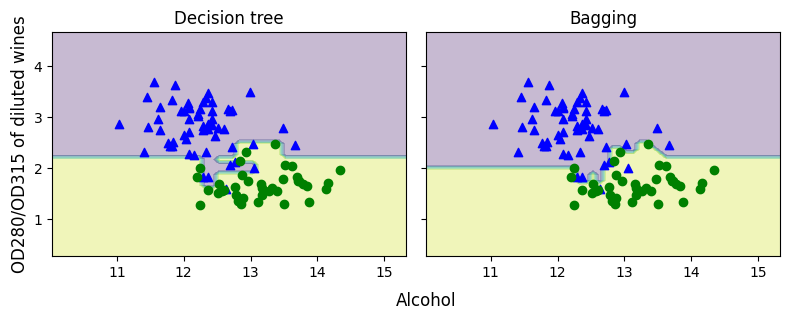

In [18]:
x_min = X_train[:, 0].min() - 1
x_max = X_train[:, 0].max() + 1
y_min = X_train[:, 1].min() - 1
y_max = X_train[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

f, axarr = plt.subplots(nrows=1, ncols=2,
                        sharex='col',
                        sharey='row',
                        figsize=(8, 3))

for idx, clf, tt in zip([0, 1],
                        [tree, bag],
                        ['Decision tree', 'Bagging']):
    clf.fit(X_train, y_train)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axarr[idx].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx].scatter(X_train[y_train==0, 0], 
                       X_train[y_train==0, 1], 
                       c='blue', marker='^')
    axarr[idx].scatter(X_train[y_train==1, 0], 
                       X_train[y_train==1, 1], 
                       c='green', marker='o')
    axarr[idx].set_title(tt)

axarr[0].set_ylabel('OD280/OD315 of diluted wines', fontsize=12)
plt.tight_layout()
plt.text(0, -0.2,
         s='Alcohol',
         ha='center',
         va='center',
         fontsize=12,
         transform=axarr[1].transAxes)
plt.show()


As we can see, bagging classifier has a smoother decision boundary compared to the piece-wise linear decision boundary of the decision tree.

### Applying AdaBoost using scikit-learn

Let's now train an AdaBoost ensemble classifier via scikit-learn using the same Wine subset that we used previously to train the bagging classifier:

In [19]:
from sklearn.ensemble import AdaBoostClassifier
tree = DecisionTreeClassifier(criterion='entropy',
                              random_state=1,
                              max_depth=1)
ada = AdaBoostClassifier(estimator=tree,
                         n_estimators=500,
                         learning_rate=0.1,
                         random_state=1)
tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)
tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)
print(f'Decision tree train/test accuracies '
      f'{tree_train:.3f}/{tree_test:.3f}')

ada = ada.fit(X_train, y_train)
y_train_pred = ada.predict(X_train)
y_test_pred = ada.predict(X_test)
ada_train = accuracy_score(y_train, y_train_pred)
ada_test = accuracy_score(y_test, y_test_pred)
print(f'AdaBoost train/test accuracies '
      f'{ada_train:.3f}/{ada_test:.3f}')

Decision tree train/test accuracies 0.916/0.875
AdaBoost train/test accuracies 0.968/0.917


We can see that the AdaBoost model has better training and test accuracies compared to the decision tree. However, we can see that we have introduced additional variance with our attempt to reduce the model bias - there is a greater gap between training and test performance. We must also note that it is considered bad practice to select a model based on the repeated usage of the test dataset. The estimate of the generalization performance may be overoptimistic.

Let's check what the decision boundaries look like:

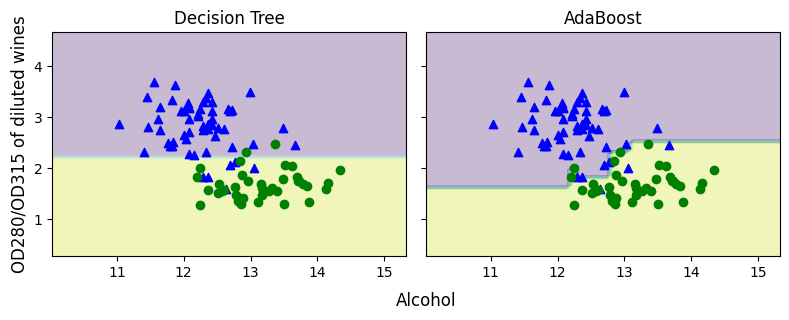

In [20]:
x_min = X_train[:, 0].min() - 1
x_max = X_train[:, 0].max() + 1
y_min = X_train[:, 1].min() - 1
y_max = X_train[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

f, axarr = plt.subplots(1, 2,
                        sharex='col',
                        sharey='row',
                        figsize=(8, 3))

for idx, clf, tt in zip([0, 1], [tree, ada], ['Decision Tree', 'AdaBoost']):
    clf.fit(X_train, y_train)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axarr[idx].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx].scatter(X_train[y_train==0, 0],
                       X_train[y_train==0, 1],
                       c='blue',
                       marker='^')
    axarr[idx].scatter(X_train[y_train==1, 0],
                       X_train[y_train==1, 1],
                       c='green',
                       marker='o')
    axarr[idx].set_title(tt)
    axarr[0].set_ylabel('OD280/OD315 of diluted wines', fontsize=12)

plt.tight_layout()
plt.text(0, -0.2,
         s='Alcohol',
         ha='center',
         va='center',
         fontsize=12,
         transform=axarr[1].transAxes)
plt.show()

We can see that the decision boundary of AdaBoost is substantially more complex than the decision boundary of the decision stump. In addition, note that the AdaBoost model separates the feature space very similary to the bagging classifier that we trained in the previous section.

### Using XGBoost

Let's use scikit-learn's implementation for XGBoost. We are going to fit the gradient boosting classifier with 1000 trees (rounds) and a learning rate of 0.01. Remember that the learning rate is used for scaling the predictions from the individual rounds. So, intuitively, the lower the learning rate, the more estimators are required to achieve accurate predictions.

In [22]:
import xgboost as xgb

model = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.01,
                          max_depth=4, random_state=1)

gbm = model.fit(X_train, y_train)
y_train_pred = gbm.predict(X_train)
y_test_pred = gbm.predict(X_test)

gbm_train = accuracy_score(y_train, y_train_pred)
gbm_test = accuracy_score(y_test, y_test_pred)

print(f'XGBoost train/test accuracies: '
      f'{gbm_train:.3f}/{gbm_test:.3f}')

XGBoost train/test accuracies: 0.968/0.917
